# RNE Density Estimator

This notebook is a tutorial of RNE for Density estimation.
We will define a diffusion model for Gaussian Mixture Model, and then demonstrate how to estimate the marginal density along the diffusion path using RNE.


## Prepare

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import OrderedDict

In [2]:
dim = 10
n_mix = 40
loc_scale = 1.0
log_var = -3.5

In [3]:
device = 'cuda'

### Define GMM Target

Note that for diffusion model on GMM, the marginal density and score are analytical. Therefore, we will define the diffusion model directly using the analytical score.

We then compare the density estimated by RNE aganist the ground truth density.

In [4]:

import torch
import numpy as np
from matplotlib import pyplot as plt
import itertools


class GMM(torch.nn.Module):
    def __init__(self, dim, n_mixes, loc_scaling, log_var_scaling=0.1, mean_shift=0,  seed=0,
                 n_test_set_samples=1000, device="cpu"):
        super(GMM, self).__init__()
        torch.manual_seed(seed)

        self.seed = seed
        self.n_mixes = n_mixes
        self.dim = dim
        self.n_test_set_samples = n_test_set_samples

        mean = (torch.rand((n_mixes, dim)) - 0.5)*2 * loc_scaling + mean_shift
        log_var = torch.ones((n_mixes, dim)) * log_var_scaling

        self.register_buffer("cat_probs", torch.ones(n_mixes))
        self.register_buffer("locs", mean)
        self.register_buffer("scale_trils", torch.diag_embed(torch.nn.functional.softplus(log_var)))
        self.device = device
        self.to(self.device)

        self.call_time = 0

    def to(self, device):
        if device == "cuda":
            if torch.cuda.is_available():
                self.cuda()
        else:
            self.cpu()

    @property
    def distribution(self):
        mix = torch.distributions.Categorical(self.cat_probs.to(self.device))
        com = torch.distributions.MultivariateNormal(self.locs.to(self.device),
                                                     scale_tril=self.scale_trils.to(self.device),
                                                     validate_args=False)
        return torch.distributions.MixtureSameFamily(mixture_distribution=mix,
                                                     component_distribution=com,
                                                     validate_args=False)

    @property
    def test_set(self) -> torch.Tensor:
        return self.sample((self.n_test_set_samples, ))

    def log_prob(self, x: torch.Tensor, count_call=True):
        log_prob = self.distribution.log_prob(x)
        mask = torch.zeros_like(log_prob)
        mask[log_prob < -1e4] = - torch.tensor(float("inf"))
        log_prob = log_prob + mask
        if count_call:
            self.call_time += x.shape[0]
        return log_prob

    def score(self, x: torch.Tensor, count_call=True):
        with torch.enable_grad():
            x.requires_grad = True
            logp = self.log_prob(x, count_call)
            score = torch.autograd.grad(logp.sum(), x)[0]
        return score 

    def sample(self, shape=(1,), count_call=True):
        if count_call:
            self.call_time += shape[0]
        return self.distribution.sample(shape)
    
    def get_sample_and_logp(self, shape=(1,), count_call=True):
        samples = self.sample(shape, count_call)
        logp = self.log_prob(samples, count_call)
        return samples, logp
    
    def get_sample_and_score(self, shape=(1,), count_call=True):
        samples = self.sample(shape, count_call)
        with torch.enable_grad():
            samples.requires_grad = True
            logp = self.log_prob(samples, count_call)
            score = torch.autograd.grad(logp.sum(), samples)[0]
        return samples.detach(), score
    

### GMM along diffusion path

class GMM_t(torch.nn.Module):
    def __init__(self, t, mean, dim, n_mixes, loc_scaling, log_var_scaling=0.1, mean_shift=0,  seed=0,
                 n_test_set_samples=1000, device="cpu"):
        super(GMM_t, self).__init__()

        self.seed = seed
        self.n_mixes = n_mixes
        self.dim = dim
        self.n_test_set_samples = n_test_set_samples

        mean = mean
        log_var = (torch.ones((n_mixes, dim)) * log_var_scaling).to(device)

        self.register_buffer("cat_probs1", torch.ones(n_mixes))
        self.register_buffer("locs1", mean)
        self.register_buffer("scale_trils1", torch.diag_embed((torch.nn.functional.softplus(log_var)**2 + t**2) ** 0.5))
        self.device = device
        self.to(self.device)

        self.call_time = 0

    def to(self, device):
        if device == "cuda":
            if torch.cuda.is_available():
                self.cuda()
        else:
            self.cpu()
        return self

    @property
    def distribution(self):
        mix = torch.distributions.Categorical(self.cat_probs1.to(self.device))
        com = torch.distributions.MultivariateNormal(self.locs1.to(self.device),
                                                     scale_tril=self.scale_trils1.to(self.device),
                                                     validate_args=False)
        return torch.distributions.MixtureSameFamily(mixture_distribution=mix,
                                                     component_distribution=com,
                                                     validate_args=False)

    @property
    def test_set(self) -> torch.Tensor:
        return self.sample((self.n_test_set_samples, ))

    def log_prob(self, x: torch.Tensor, count_call=True):
        log_prob = self.distribution.log_prob(x)
        log_prob = log_prob
        if count_call:
            self.call_time += x.shape[0]
        return log_prob

    def score(self, x: torch.Tensor, count_call=True):
        with torch.enable_grad():
            x.requires_grad = True
            logp = self.log_prob(x, count_call)
            score = torch.autograd.grad(logp.sum(), x)[0]
        return score 

    def sample(self, shape=(1,), count_call=True):
        if count_call:
            self.call_time += shape[0]
        return self.distribution.sample(shape)
    
    def get_sample_and_logp(self, shape=(1,), count_call=True):
        samples = self.sample(shape, count_call)
        logp = self.log_prob(samples, count_call)
        return samples, logp
    
    def get_sample_and_score(self, shape=(1,), count_call=True):
        samples = self.sample(shape, count_call)
        with torch.enable_grad():
            samples.requires_grad = True
            logp = self.log_prob(samples, count_call)
            score = torch.autograd.grad(logp.sum(), samples)[0]
        return samples.detach(), score

In [5]:
gmm = GMM(dim, n_mix, loc_scale, log_var)

## RNE Density Estimator (RNDE)

#### Intuitive Explanation of RNDE

RNE is based on the following observation:

> For a well trained diffusion model, the forward process (noising process) and the backward process (denoising process) defines the same probabilty distribution.

The forward process from $t_n$ is: $$p_n(x_n)p(x_{n+1}|x_n) \cdots p(x_{N}|x_{N-1})$$
The transiton kernels $p(x_{n+1}|x_n) \cdots p(x_{N}|x_{N-1})$ are simply Gaussian noising kernels.

The backward process from $t_n$ is: $$p_N(x_N)p(x_{N-1}|x_N) \cdots p(x_{n}|x_{n+1})$$
The transiton kernels $p_N(x_N)p(x_{N-1}|x_N) \cdots p(x_{n}|x_{n+1})$ are simply Gaussian denoising kernels (with the learned score network), and $p_N(x_N)$ is a Gaussian distribution.

Therefore, 
\begin{align}
p_n(x_n) = \frac{p_N(x_N)p(x_{N-1}|x_N) \cdots p(x_{n}|x_{n+1})}{p(x_{n+1}|x_n) \cdots p(x_{N}|x_{N-1})} \tag{*}
\end{align}


This is an intuitive explanation to the RNE in discrete time. In continuous-time limit, we also provide its form in the paper. 

#### RNDE with Analytical Reference

In our paper, we introduce an analytical reference to reduce the error of RNE.

An intuitive motivation for the reference is as follows. The discretisation error for forward process and backward process is different. Even the estimator is valid in continuous time, it does not mean there is numerical-error free in discrete time. To reduce the error, a better way is to introduce a pair of forward-forward process (or backward-backward), instead of a forward-backward pair.

Luckily, for the diffusion model we typically choose, if we start from a Gaussian distribution, then we know everything for the process: the marginal, the score, the transition kernel, etc. Therefore, we can directly write down its forward and backward process:

\begin{align}
 &\pi_n(x_n)\pi(x_{n+1}|x_n) \cdots \pi(x_{N}|x_{N-1})\\ &= \\ &\pi_N(x_N)\pi(x_{N-1}|x_N) \cdots \pi(x_{n}|x_{n+1})
\end{align}


For example, in our example in this notebook, we start from a Gaussian $\pi_0=\mathcal{N}(0, I)$, and the noising process follows EDM. Therefore, $\pi_t=\mathcal{N}(0, (1+t^2)I)$. Using this we can calculate the forward and backward transition kernel. In the code, this is done by 

```python
# analytical marginal std and score
ref_std = lambda time: (1**2 + time ** 2)**0.5
ref_score = lambda x, time: - x / ref_std(time) ** 2

# ref forward process
fwd_mean = samples_new
fwd_std = torch.sqrt(2*Delta_t*t_1)
ref_fwd = log_norm_prob(samples_new, 0, ref_std(t_1)) # marginal density at t_1
ref_fwd += log_norm_prob(samples, fwd_mean, fwd_std) # transition kernel density from t to t_1

# ref backward process
bwd_mean = samples + ref_score(samples, t) * 2 * t * Delta_t
bwd_std = torch.sqrt(2*Delta_t*t)
ref_bwd = log_norm_prob(samples, 0, ref_std(t)) # marginal density at t
ref_bwd += log_norm_prob(samples_new, bwd_mean, bwd_std) # transition kernel density from t_1 to t

```


From equation (1)-(3), we know in the ideal case, (1) should be the same  as (3). Therefore, we can freely add (1)/(3) to our previous estimator (*).


This gives us a more stable and more accurate estimator:


\begin{align}
p_n(x_n) = \frac{p_N(x_N)p(x_{N-1}|x_N) \cdots p(x_{n}|x_{n+1})}{\pi_N(x_N)\pi(x_{N-1}|x_N) \cdots \pi(x_{n}|x_{n+1})}
\frac{\pi_n(x_n)\pi(x_{n+1}|x_n) \cdots \pi(x_{N}|x_{N-1})}{p(x_{n+1}|x_n) \cdots p(x_{N}|x_{N-1})} \tag{**}
\end{align}








#### Experiments

Now, let's look at the codes and experiments

In [6]:
def log_norm_prob(x, mu, std):
    """
    Gaussian log density
    """
    # expand std to match x shape
    std = std.expand(x.shape)
    return -0.5 * ((x - mu) / std).pow(2).sum(-1) - (std.log() + np.log(2*np.pi)/2).sum(-1)


In [8]:
def gmm_score(gmm, x: torch.Tensor):
    with torch.enable_grad():
        # x.requires_grad = True
        logp = gmm.log_prob(x)
        score = torch.autograd.grad(logp.sum(), x, create_graph=True)[0]
    return score 

Main RNDE Function

In [10]:
def EM_solve_RNE(start_samples, start_logp):
    torch.manual_seed(0)
    with torch.no_grad():
        samples = start_samples
        logp = start_logp
        logp_ref = start_logp
        logp_ito = start_logp

        # we will keep track of 4 values.
        Samples = []
        Logps = [start_logp] # RNDE without reference at each step
        Logps_ito = [start_logp] # Ito Density Estimator (we show it is equivalent to RNDE in continuous time) as a baseline
        True_logp = [start_logp] # Ground truth 
        Logps_Ref = [start_logp] # RNDE with reference at each step


        for i in tqdm(range(ts.shape[0]-1, 0, -1)):
            t = torch.ones(samples.shape[0], 1).to(samples.device) * ts[i]
            t_1 = torch.ones(samples.shape[0], 1).to(samples.device) * ts[i-1]

            Delta_t = (t - t_1).abs()
            std = torch.sqrt(2*Delta_t*t)

            # calculate GMM at time step t to get the score for diffusion model
            _gmm = GMM_t(t[0], gmm.locs, dim, n_mix, loc_scale, log_var, device=device).to(device)
            score = _gmm.score(samples, count_call=False).to(device)

            dx = score * 2 * t * Delta_t + std * torch.randn_like(samples) 

            samples_new = samples + dx


            # diffusion forward process
            fwd_mean = samples_new
            fwd_std = torch.sqrt(2*Delta_t*t_1)
            dm_fwd = log_norm_prob(samples, fwd_mean, fwd_std) 

            # diffusion backward process
            bwd_mean = samples + score * 2 * t * Delta_t
            bwd_std = torch.sqrt(2*Delta_t*t)
            dm_bwd = log_norm_prob(samples_new, bwd_mean, bwd_std)

            # first define reference distribution
            ref_std = lambda time: (1**2 + time ** 2)**0.5
            ref_score = lambda x, time: - x / ref_std(time) ** 2
            # ref forward process
            fwd_mean = samples_new
            fwd_std = torch.sqrt(2*Delta_t*t_1)
            ref_fwd = log_norm_prob(samples_new, 0, ref_std(t_1)) + log_norm_prob(samples, fwd_mean, fwd_std) 

            # ref backward process
            bwd_mean = samples + ref_score(samples, t) * 2 * t * Delta_t
            bwd_std = torch.sqrt(2*Delta_t*t)
            ref_bwd = log_norm_prob(samples, 0, ref_std(t)) + log_norm_prob(samples_new, bwd_mean, bwd_std)


            logp = logp + (dm_bwd - dm_fwd)
            logp_ito = logp_ito + (dx*score - score**2 * 1/2 * 2*t * Delta_t).sum(-1)
            logp_ref = logp_ref + (dm_bwd - ref_bwd - dm_fwd + ref_fwd)
            samples = samples_new.clone()

            
            Samples.append(samples)
            Logps.append(logp)
            Logps_ito.append(logp_ito)
            Logps_Ref.append(logp_ref)


            # copy torch seed state
            _gmm = GMM_t(t_1[0], gmm.locs, dim, n_mix, loc_scale, log_var, device=device).to(device)
            True_logp.append(_gmm.log_prob(samples))
           
        return Samples, Logps, Logps_ito, Logps_Ref, True_logp

In [11]:

ALL_RES = {}
for steps in [100, 200, 400]:
    tmax = 10
    tmin = 1e-3
    rho = 7
    steps = steps

    ts = tmin ** (1/rho) + np.arange(steps)/(steps-1) * (tmax ** (1/rho) - tmin ** (1/rho))
    ts = ts ** rho

        
    init_samples = torch.randn(1000, dim, device=device)*ts[-1]
    init_logp = log_norm_prob(init_samples, torch.zeros_like(init_samples), torch.ones_like(init_samples)*ts[-1])
    Samples, Logps, Logps_ito, Logps_Ref, True_logp  = EM_solve_RNE(init_samples, init_logp)

    ALL_RES[steps] = Samples, Logps, Logps_ito, Logps_Ref, True_logp


100%|██████████| 399/399 [00:04<00:00, 89.23it/s]


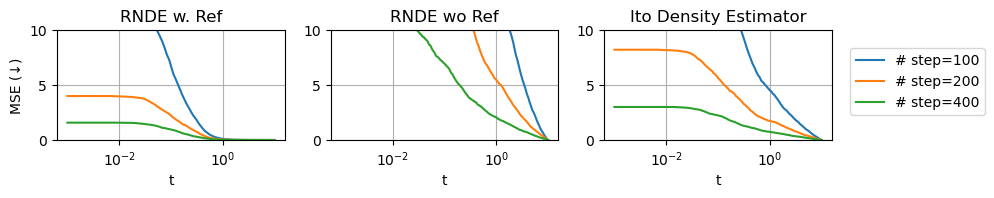

In [12]:
# set the gap between subplots
plt.figure(figsize=(10, 10/7))
plt.subplots_adjust(wspace=0.2, hspace=0.6) 

ylim = [-0.01, 10.0]

for steps in [100, 200, 400]:
    (Samples, Logps, Logps_ito, Logps_Ref, True_logp) = ALL_RES[steps]
    tmax = 10
    tmin = 1e-3
    rho = 7
    steps = steps

    ts = tmin ** (1/rho) + np.arange(steps)/(steps-1) * (tmax ** (1/rho) - tmin ** (1/rho))
    ts = ts ** rho
    plt.subplot(1, 3, 1)
    plt.plot(ts[::-1], 
        ((torch.stack(Logps_Ref).cpu() - torch.stack(True_logp).cpu())**2).mean(-1).numpy()
        ,label='# step=%d'%steps)
    plt.xlabel('t')
    plt.ylabel('MSE (↓)')
    plt.xscale('log')
    plt.title('RNDE w. Ref')
    plt.ylim(*ylim)
    plt.grid()


    plt.subplot(1, 3, 2)
    plt.plot(ts[::-1], 
        ((torch.stack(Logps).cpu() - torch.stack(True_logp).cpu())**2).mean(-1).numpy()
        ,label='# step=%d'%steps
        )
    plt.xlabel('t')
    plt.xscale('log')
    plt.title('RNDE wo Ref')
    plt.ylim(*ylim)
    plt.grid()



    plt.subplot(1, 3, 3)
    plt.plot(ts[::-1], 
        ((torch.stack(Logps_ito).cpu() - torch.stack(True_logp).cpu())**2).mean(-1).numpy()
        ,label='# step=%d'%steps
        )
    plt.xlabel('t')
    plt.xscale('log')
    plt.title('Ito Density Estimator')
    plt.ylim(*ylim)
    plt.grid()


    # move legend outside of the plot
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 0.9), fontsize=10)
